In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os

/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
read_one_case = True
full_years = True
plot_2d_comparison = True
plot_corrected = False

In [3]:
# Exp: longrun_10years_newgraph_90s_uncorr, shortname: train16yr_uncorr_10d_100k, number of files found: 36
# Exp: longrun_10years_newgraph_90s_corrected, shortname: train16yr_corr_10d_100k, number of files found: 36
# Exp: longrun_10years_newgraph_90s_uncorr, shortname: train16yr_uncorr_1year_100k, number of files found: 6
# Exp: longrun_10years_newgraph_90s_corrected, shortname: train16yr_corr_1year_100k, number of files found: 6
# Exp: longrun_5years_newgraph_90s_uncorr, shortname: train4yr_uncorr_10d_25k, number of files found: 36
# Exp: longrun_5years_newgraph_90s_uncorr, shortname: train4yr_uncorr_1year_25k, number of files found: 6

In [4]:
commondir = '/lustre/storeB/users/nilsmk/anemoi-datasets/output'
#
# step = '183000'
# # Xaver case:
# if not plot_corrected:
#     ifile = f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/xaver_2013-12-01_240h_step{step}.nc'
#     odir  = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/xaver_case'
# else:
#     ifile = f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/xaver_2013-12-01_240h_step{step}.nc'
#     odir  = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/figures/xaver_case'
# prefix = f'step{step}_'

# ifile = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/lam-8760h_test.nc'
# odir  = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/figures/oneyear'
# prefix = 'lam-8760h_'

# if not plot_corrected:
#     odir = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/'
# else:
#     odir = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/figures/'

# idir = os.path.join(commondir, 'longrun_graph10.3_1980-2012/inference')
# ifile = os.path.join(idir, '2013-12-01_xaver2013_step060000.nc')
# odir = os.path.join(idir, 'figures', 'xaver_case')

### Runs for manuscript pr 26. nov 25:
step  = 100000
# Train 16 years, uncorrected or corrected, 10-day or 1-year files
# Uncorrected directory:
idir  = os.path.join(commondir, 'longrun_10years_newgraph_90s_uncorr/inference')
# idir  = os.path.join(commondir, 'longrun_5years_newgraph_90s_uncorr/inference')
# # # For 10-day files:
# # ifile = os.path.join(idir, f'2013-01-01_240h_step{step}.nc')
# # prefix = 'train16yr_{}_10d_{}'
# # multiyear_filestruct = os.path.join(idir, f'????-??-??_240h_step{step}.nc')
# # For 1-year files:
# ifile = os.path.join(idir, f'2013-01-01_1year_step{step}.nc')
# prefix = 'train16yr_{}_1year_{}'
# multiyear_filestruct = os.path.join(idir, f'????-??-??_1year_step{step}.nc')
# For 2010-2018 period:
ifile = os.path.join(idir, 'long_2010-01-02_78840h_step100000.nc')

# # Train 5 years, uncorrected, 10-day or 1-year files
# # step  = 25000
# # step  = 50000
# # step  = 75000
# # step  = 100000
# # idir  = os.path.join(commondir, 'longrun_5years_newgraph_90s_uncorr/inference')
# idir  = os.path.join(commondir, 'longrun_10years_newgraph_90s_uncorr/inference')
# # # For 10-day files:
# ifile = os.path.join(idir, f'2013-01-01_240h_step{step:06d}.nc')
# # prefix = 'train4yr_{}_10d_{}'
# prefix = 'train16yr_{}_10d_{}'
# multiyear_filestruct = os.path.join(idir, f'????-??-??_240h_step{step:06d}.nc')
# # # For 1-year files:
# # ifile = os.path.join(idir, f'2013-01-01_1year_step{step}.nc')
# # prefix = 'train4yr_{}_1year_{}'
# # multiyear_filestruct = os.path.join(idir, f'????-??-??_1year_step{step}.nc')

# Define output directory
odir  = os.path.join(idir, 'figures')

# Ensure ifile exists
if not os.path.exists(ifile):
    raise FileNotFoundError(f"Input file {ifile} does not exist.")

In [18]:
# Selected time period for comparison
# # Xaver:
# t1 = np.datetime64('2013-12-05T00:00:00')
# t2 = np.datetime64('2013-12-07T00:00:00')
# prefix = 'train16yr_uncorr_2010-2018_xaver_'
# # Inga:
# t1 = np.datetime64('2005-01-11T00:00:00')
# t2 = np.datetime64('2005-01-14T00:00:00')
# prefix = 'train16yr_uncorr_2010-2018_inga_'
# Full year:
t1 = np.datetime64('2010-01-01T00:00:00')
t2 = np.datetime64('2019-01-01T00:00:00 ')
prefix = 'train16yr_uncorr_2010-2018_'
# prefix = 'train4yr_uncorr_2010-2018_'

/tmp/ipykernel_2426254/2511874390.py:12: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  t2 = np.datetime64('2019-01-01T00:00:00 ')


In [6]:
# Compare with NORA-surge:
yy = t1.astype('datetime64[Y]').astype(int) + 1970
comparewith = f'/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/{yy}/ocean_his.nc'
if plot_corrected:
    comparewith2 = f'/lustre/storeB/users/nilsmk/stormrisk/nora3_v2_corrected/{yy}/ocean_his.nc'

In [7]:
# Compare with entire nora surge 2010-2018:
comparefiles = []
for year in range(2010, 2019):
    comparefiles.append(f'/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/{year}/ocean_his.nc')
comparewith = comparefiles

In [8]:
# comparewith = "/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/{2010..2018}/ocean_his.nc"

In [9]:
print(comparewith)

['/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/2010/ocean_his.nc', '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/2011/ocean_his.nc', '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/2012/ocean_his.nc', '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/2013/ocean_his.nc', '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/2014/ocean_his.nc', '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/2015/ocean_his.nc', '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/2016/ocean_his.nc', '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/2017/ocean_his.nc', '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/2018/ocean_his.nc']


In [10]:
# Create odir if it does not exist
import os
if not os.path.exists(odir):
    os.makedirs(odir)

In [11]:
# nc_c = xr.open_dataset(comparewith)
nc_c = xr.open_mfdataset(comparewith)
zeta_c = nc_c.zeta[:,5:575,5:1019]  # cut away the outermost grid cells to match the lam grid
lat_c = nc_c.lat_rho[5:575,5:1019]
lon_c = nc_c.lon_rho[5:575,5:1019]
time_c = nc_c.ocean_time
try:
    mask_c = nc_c.mask_rho[5:575,5:1019]
except IndexError:
    mask_c = nc_c.mask_rho[0,5:575,5:1019]
ymask, xmask = np.where(mask_c==1)
timee_c = np.array([np.datetime64(t) for t in time_c.values])
if plot_corrected:
    nc_c2 = xr.open_dataset(comparewith2)
    zeta_c2 = nc_c2.zeta[:,5:575,5:1019]  # cut away the outermost grid cells to match the lam grid

/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/xarray/backends/plugins.py:64: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'deprecated' from 'typing_extensions' (/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/typing_extensions.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


ValueError: too many values to unpack (expected 2)

In [ ]:
nc_c.mask_rho.shape

(580, 1024)

In [ ]:
mask_c.shape

(570, 1014)

### Do one case study

In [32]:
if read_one_case:
    print(f'Reading inference data from {ifile}... between {t1} and {t2}')
    nc = xr.open_dataset(ifile)
    # Only select the time period of interest
    nc = nc.sel(time=slice(t1, t2))
    zeta = nc.zeta
    lat = nc.latitude
    lon = nc.longitude
    time = nc.time
    # x_wind_10m = nc.x_wind_10m
    #
    zeta2 = np.reshape(zeta.values, (zeta.shape[0], 570, 1014))
    lat2 = np.reshape(lat.values, (570, 1014))
    lon2 = np.reshape(lon.values, (570, 1014))
    # x_wind_10m2 = np.reshape(x_wind_10m.values, (x_wind_10m.shape[0], 570, 1014))

Reading inference data from /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/long_2010-01-02_78840h_step100000.nc... between 2010-01-01T00:00:00 and 2019-01-01T00:00:00


MemoryError: Unable to allocate 170. GiB for an array with shape (78841, 577980) and data type float32

In [ ]:
if read_one_case:
    # Find index of time in time_c
    timee = np.array([np.datetime64(t) for t in time.values])
    timee_c = np.array([np.datetime64(t) for t in time_c.values])
    time_indices = np.where((timee_c >= timee[0]) & (timee_c <= timee[-1]))[0]

In [ ]:
if read_one_case and plot_2d_comparison:
    import warnings
    warnings.filterwarnings('ignore', category=UserWarning) # Suppress UserWarnings
    # Plot the same as above, but with two subplots, one for the inference and one for the comparison
    minval = 0.0
    maxval = 3.0
    # colormap = 'RdBu_r'
    colormap = 'inferno'
    # for i in range(0, 180, 3):
    for i in range(0, len(time), 1):
        time_str = np.datetime_as_string(timee_c[time_indices[i]], unit='h')
        fig, (ax2, ax1, ax3) = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
        pcm1 = ax1.pcolormesh(lon2, lat2, zeta2[i,:,:], cmap=colormap, vmin=minval, vmax=maxval)
        # Add a grey land mask where mask_c == 0
        ax1.pcolormesh(lon_c, lat_c, np.ma.masked_where(mask_c == 1, mask_c), cmap='tab20c_r')
        # ax1.set_title(f'Inference\nTime index: {i}')
        # ax1.set_title('Flo')
        ax1.set_title(f'Time: {time_str}00\nFlo')
        fig.colorbar(pcm1, ax=ax1, label='zeta[m]')
        if plot_corrected:
            pcm2 = ax2.pcolormesh(lon_c, lat_c, zeta_c2[time_indices[i], :, :]*mask_c, cmap=colormap, vmin=minval, vmax=maxval)
            print(f'Using corrected comparison data for time index {i}')
        else:
            pcm2 = ax2.pcolormesh(lon_c, lat_c, zeta_c[time_indices[i], :, :]*mask_c, cmap=colormap, vmin=minval, vmax=maxval)
        # Add a grey land mask where mask_c == 0
        ax2.pcolormesh(lon_c, lat_c, np.ma.masked_where(mask_c == 1, mask_c), cmap='tab20c_r')
        # ax2.set_title(f'Comparison\nTime index: {time_indices[i]}, Time value: {timee_c[time_indices[i]]}')
        # Format the time in timee_c[time_indices[i]] nicely:
        # ax2.set_title(f'Time: {time_str}00\nNORA-surge')
        ax2.set_title('NORA-surge')
        fig.colorbar(pcm2, ax=ax2, label='zeta[m]')
        pcm3 = ax3.pcolormesh(lon_c, lat_c, zeta2[i,:,:]-zeta_c[time_indices[i], :, :]*mask_c, cmap='RdYlBu_r', vmin=-0.25, vmax=0.25)
        # Add a grey land mask where mask_c == 0
        ax3.pcolormesh(lon_c, lat_c, np.ma.masked_where(mask_c == 1, mask_c), cmap='tab20c_r')
        # ax3.set_title(f'Difference\nTime index: {i}')
        ax3.set_title(f'Difference (Flo - NORA-surge)')
        fig.colorbar(pcm3, ax=ax3, label='zeta[m]')
        # For all ax, zoom in to the same region (e.g., the North Sea)
        for ax in (ax1, ax2, ax3):
            ax.set_xlim(0.0, 12.0)  # Longitude limits for North Sea
            ax.set_ylim(50.0, 60.0)  # Latitude limits for North Sea
        plt.tight_layout()
        plt.savefig(os.path.join(odir, f'{prefix}zeta_compare_{i:04d}.png'), dpi=100)
        # plt.show()
        plt.close()
        print(f'Plotted index {i}, number of plots left: {len(time)-i-1}, filename: {os.path.join(odir, f"{prefix}zeta_compare_{i:04d}.png")}')

Plotted index 0, number of plots left: 48, filename: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/train16yr_uncorr_2010-2018_xaver_zeta_compare_0000.png
Plotted index 1, number of plots left: 47, filename: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/train16yr_uncorr_2010-2018_xaver_zeta_compare_0001.png
Plotted index 2, number of plots left: 46, filename: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/train16yr_uncorr_2010-2018_xaver_zeta_compare_0002.png
Plotted index 3, number of plots left: 45, filename: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/train16yr_uncorr_2010-2018_xaver_zeta_compare_0003.png
Plotted index 4, number of plots left: 44, filename: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inferenc

In [ ]:
# Rename all the files to have leading zeros in the index for proper sorting
if False:
    for filename in os.listdir(odir):
        if filename.startswith(f'{prefix}zeta_compare_') and filename.endswith('.png'):
            parts = filename.split('_')
            index_part = parts[-1].split('.')[0]
            index_int = int(index_part)
            new_filename = f'{prefix}zeta_compare_{index_int:04d}.png'
            os.rename(os.path.join(odir, filename), os.path.join(odir, new_filename))
            print(f'Renamed {filename} to {new_filename}')

In [ ]:
if read_one_case:
    # Using "convert" in os.system to create a gif from the png files
    os.system(f'convert -delay 10 -loop 0 {odir}/{prefix}zeta_compare*.png {odir}/{prefix}zeta.gif')
    print(f'{odir}/{prefix}zeta.gif created successfully.')

/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/figures/oneyear/lam-8760h_zeta.gif created successfully.


In [ ]:
# LIst all the gif files in odir
gif_files = [f for f in os.listdir(odir) if f.endswith('.gif')]
print('GIF files in output directory:')
for gif in gif_files:
    print(os.path.join(odir, gif))

GIF files in output directory:


TODO: Plot timseries for all runs, start with Cuxhaven

In [ ]:
# Read obs:
idir_obs          = '/lustre/storeB/users/nilsmk/stormrisk'
ifile_tseries_obs = os.path.join(idir_obs, 'aggregated_water_level_observations_with_pytide_prediction_dataset_extended_nor_stations_with_4_nora-surge_exps.nc')
nc_timeseries_selected = xr.open_dataset(ifile_tseries_obs)

In [ ]:
if read_one_case:
    # Cuxhaven coordinates
    sta_lat = 53.87
    sta_lon = 8.72
    staname = 'Cuxhaven'
    sta_idx = np.where(nc_timeseries_selected.stationid[:].values == 'DE_Cuxhaven')[0][0]
    # Oscarsborg coordinates 66 NO_OSC 59.678074 10.604861
    # sta_lat = 59.68
    # sta_lon = 10.60
    # staname = 'Oscarsborg'
    # sta_idx = np.where(nc_timeseries_selected.stationid[:].values == 'NO_OSC')[0][0]
    # Bergen coordinates 53 NO_BGO 60.398045 5.320487
    # sta_lat = 60.40
    # sta_lon = 5.32
    # staname = 'Bergen'
    # sta_idx = np.where(nc_timeseries_selected.stationid[:].values == 'NO_BGO')[0][0]
    # Do the same for the comparison data
    lat_c_arr = np.array(lat_c[:])
    lon_c_arr = np.array(lon_c[:])
    dist_c = np.sqrt((lat_c_arr - sta_lat)**2 + (lon_c_arr - sta_lon)**2)
    min_index_c = np.unravel_index(np.argmin(dist_c), dist_c.shape)
    print(f'Nearest point to {staname} in comparison data: lat={lat_c_arr[min_index_c]}, lon={lon_c_arr[min_index_c]} at index {min_index_c}')
    # If land point, find new position:
    if mask_c[min_index_c] == 0:
        print('Nearest point is on land, searching for nearest sea point...')
        sea_indices = np.where(mask_c == 1)
        sea_lats = lat_c_arr[sea_indices]
        sea_lons = lon_c_arr[sea_indices]
        dist_sea = np.sqrt((sea_lats - sta_lat)**2 + (sea_lons - sta_lon)**2)
        min_sea_index = np.argmin(dist_sea)
        min_index_c = (sea_indices[0][min_sea_index], sea_indices[1][min_sea_index])
        print(f'New nearest sea point: lat={lat_c_arr[min_index_c]}, lon={lon_c_arr[min_index_c]} at index {min_index_c}')
        # Update sta_lat and sta_lon
        sta_lat = lat_c_arr[min_index_c]
        sta_lon = lon_c_arr[min_index_c]
    # Find the nearest point in the lat/lon grid
    import numpy as np
    lat_arr = np.array(lat[:])
    lon_arr = np.array(lon[:])
    dist = np.sqrt((lat_arr - sta_lat)**2 + (lon_arr - sta_lon)**2)
    min_index = np.unravel_index(np.argmin(dist), dist.shape)
    print(f'Nearest point to {staname}: lat={lat_arr[min_index]}, lon={lon_arr[min_index]} at index {min_index}')

Nearest point to Cuxhaven in comparison data: lat=53.877716064453125, lon=8.72961711883545 at index (1, 259)
Nearest point is on land, searching for nearest sea point...
New nearest sea point: lat=53.926902770996094, lon=8.723377227783203 at index (2, 260)
Nearest point to Cuxhaven: lat=53.926902770996094, lon=8.723377227783203 at index (2288,)


In [ ]:
import glob
# if plot_corrected:
# ifiles = glob.glob('/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/xaver_2013-12-01_240h_step*.nc')
# else:
# ifiles = glob.glob('/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/xaver_2013-12-01_240h_step*.nc')
# ifiles = glob.glob(f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_*/inference/xaver_2013-12-01_240h_step{step}.nc')
# ifiles = glob.glob(f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/????-??-??_240h_step{step}.nc')
# ifiles = glob.glob(f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/????-??-??_240h_step{step}.nc')
ifiles = glob.glob(os.path.join(idir, f'????-??-??_xaver2013_step*.nc'))
ifiles.sort()
prefix = 'longrun30yrs_'

In [ ]:
for ifile in ifiles:
    print(f'Processing file: {ifile}')

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step060000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step090000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step120000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step150000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step180000.nc


In [ ]:
# Read obs:
# selected_timeseries = (nc_timeseries_selected['observation']-nc_timeseries_selected['pytide_prediction']).sel(time=slice(time[0], time[-1]))[:,sta_idx]
selected_timeseries = nc_timeseries_selected.sel(time=slice(time[0], time[-1]))
obs_surge = (selected_timeseries['observation']-selected_timeseries['pytide_prediction'])[sta_idx,:]*0.01  # Convert cm to m

RMSE for step 060000: 0.1478 m
RMSE for step 090000: 0.2361 m
RMSE for step 120000: 0.1880 m
RMSE for step 150000: 0.0897 m
RMSE for step 180000: 0.1108 m


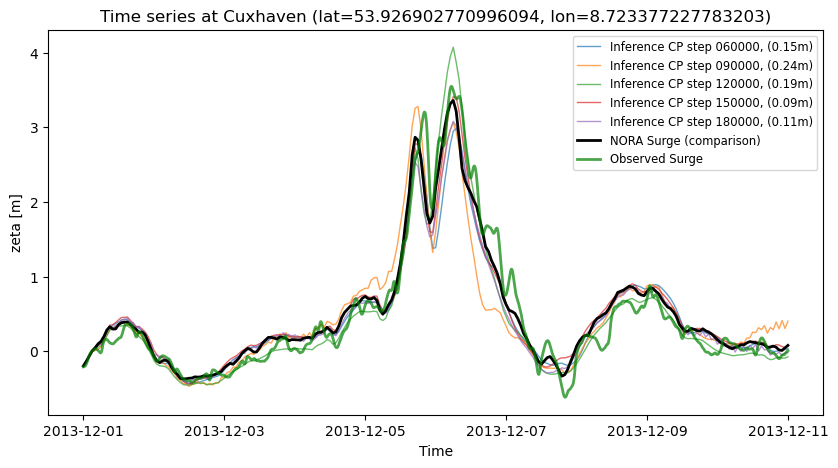

In [ ]:
#
# Plot the time series for the station for all inference runs and the comparison data in one plot
fig, ax = plt.subplots(figsize=(10, 5))
for file in ifiles:
    nc = xr.open_dataset(file)
    zeta = nc.zeta
    time = nc.time
    # Calculate RMSE for this time series compared to the comparison data
    zeta_c_series = zeta_c[time_indices, min_index_c[0], min_index_c[1]].values
    zeta_series = zeta[:, min_index[0]].values
    rmse = np.sqrt(np.mean((zeta_series - zeta_c_series)**2))
    print(f'RMSE for step {file[-9:-3]}: {rmse:.4f} m')
    ax.plot(time, zeta[:, min_index[0]], label=f'Inference CP step {file[-9:-3]}, ({rmse:.2f}m)', lw=1, alpha=0.7)
# Plot the comparison data time series
ax.plot(time_c[time_indices], zeta_c[time_indices, min_index_c[0], min_index_c[1]], label='NORA Surge (comparison)', lw=2, color='k')
if plot_corrected:
    ax.plot(time_c[time_indices], zeta_c2[time_indices, min_index_c[0], min_index_c[1]], label='NORA Surge Corrected (comparison)', lw=2, color='orange')
# Plot obs surge:
ax.plot(selected_timeseries.time, obs_surge, label='Observed Surge', lw=2, color='green', alpha=0.7)
ax.set_title(f'Time series at {staname} (lat={sta_lat}, lon={sta_lon})')
ax.set_xlabel('Time')
ax.set_ylabel('zeta [m]')
ax.legend(fontsize='small')
plt.savefig(os.path.join(odir, f'{prefix}zeta_timeseries_{staname}.png'), dpi=100)
plt.show()

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step060000.nc
RMSE for step 060000: 0.1478 m


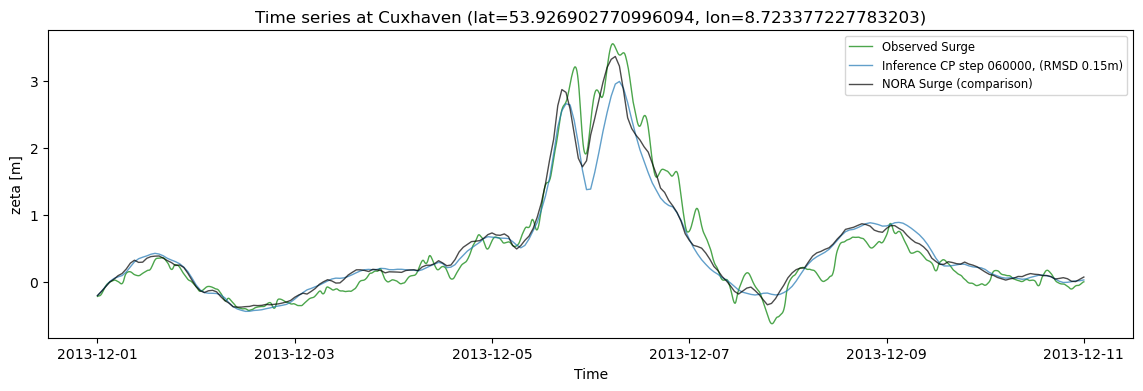

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step090000.nc
RMSE for step 090000: 0.2361 m


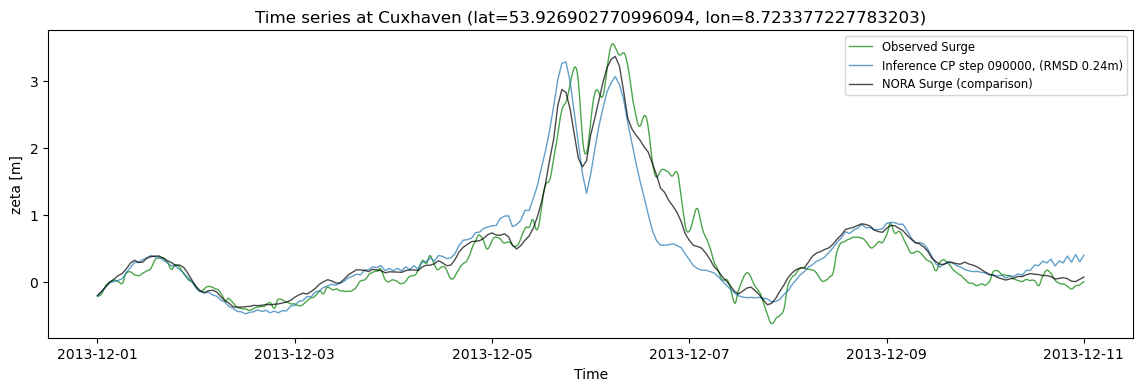

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step120000.nc
RMSE for step 120000: 0.1880 m


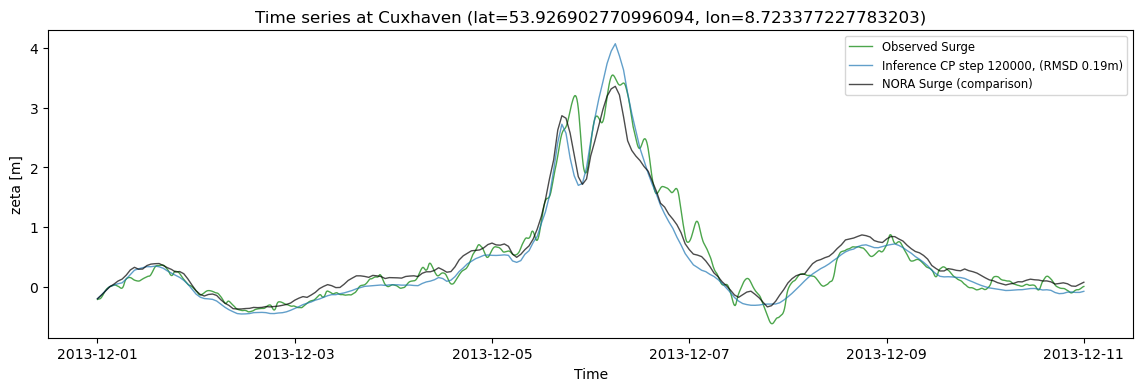

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step150000.nc
RMSE for step 150000: 0.0897 m


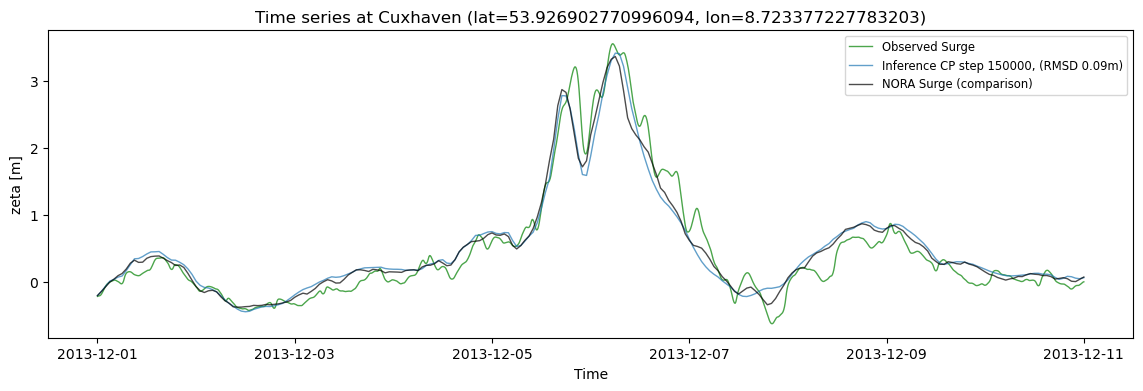

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step180000.nc
RMSE for step 180000: 0.1108 m


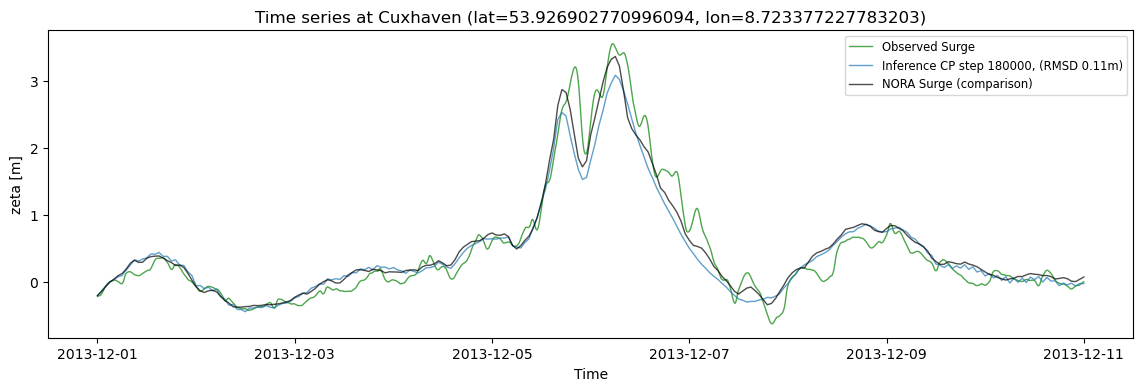

In [ ]:
if True:
    linewdth = 1
    # Plot the individual time series
    for file in ifiles:
        print(f'Processing file: {file}')
        fig, ax = plt.subplots(figsize=(14, 4))
        # Plot obs surge:
        ax.plot(selected_timeseries.time, obs_surge, label='Observed Surge', lw=linewdth, color='green', alpha=0.7)
        nc = xr.open_dataset(file)
        zeta = nc.zeta
        time = nc.time
        zeta_series = zeta[:, min_index[0]].values
        # Calculate RMSE for this time series compared to the comparison data
        if plot_corrected:
            zeta_c_series2 = zeta_c2[time_indices, min_index_c[0], min_index_c[1]]
        zeta_c_series = zeta_c[time_indices, min_index_c[0], min_index_c[1]]
        try:
            if plot_corrected:
                rmse = np.sqrt(np.mean((zeta_series - zeta_c_series.values)**2))
            else:
                rmse = np.sqrt(np.mean((zeta_series - zeta_c_series.values)**2))
        except:
            rmse = np.nan
        ax.plot(time, zeta[:, min_index[0]], label=f'Inference CP step {file[-9:-3]}, (RMSD {rmse:.2f}m)', lw=linewdth, alpha=0.7)
        # Plot the comparison data time series
        ax.plot(time_c[time_indices], zeta_c_series, label='NORA Surge (comparison)', lw=linewdth, color='k', alpha=0.7)
        if plot_corrected:
            ax.plot(time_c[time_indices], zeta_c_series2, label='NORA Surge Corrected (comparison)', lw=linewdth, color='grey', alpha=0.7)
        print(f'RMSE for step {file[-9:-3]}: {rmse:.4f} m')
        ax.set_title(f'Time series at {staname} (lat={sta_lat}, lon={sta_lon})')
        ax.set_xlabel('Time')
        ax.set_ylabel('zeta [m]')
        ax.legend(fontsize='small')
        # plt.savefig(os.path.join(odir, f'{prefix}zeta_timeseries_{staname}.png'), dpi=100)
        plt.show()

In [ ]:
# Calulate RMSE between inference and NORA surge for all time steps for all runs, and plot as time series
rmse = np.zeros((len(ifiles), len(time)))
for ifile_idx, ifile in enumerate(ifiles):
    print(f'Processing file: {ifile}')
    nc = xr.open_dataset(ifile)
    zeta = nc.zeta
    zeta2 = np.reshape(zeta.values, (zeta.shape[0], 570, 1014))
    for i in range(len(time)):
        if plot_corrected:
            rmse[ifile_idx, i] = np.sqrt(np.mean((zeta2[i,:,:]-zeta_c2[time_indices[i], :, :]*mask_c)**2))
        else:
            rmse[ifile_idx, i] = np.sqrt(np.mean((zeta2[i,:,:]-zeta_c[time_indices[i], :, :]*mask_c)**2))


Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step060000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step090000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step120000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step150000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step180000.nc


RMSD time series plot saved to /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/figures/xaver_case/longrun30yrs_zeta_rmsd_timeseries.png


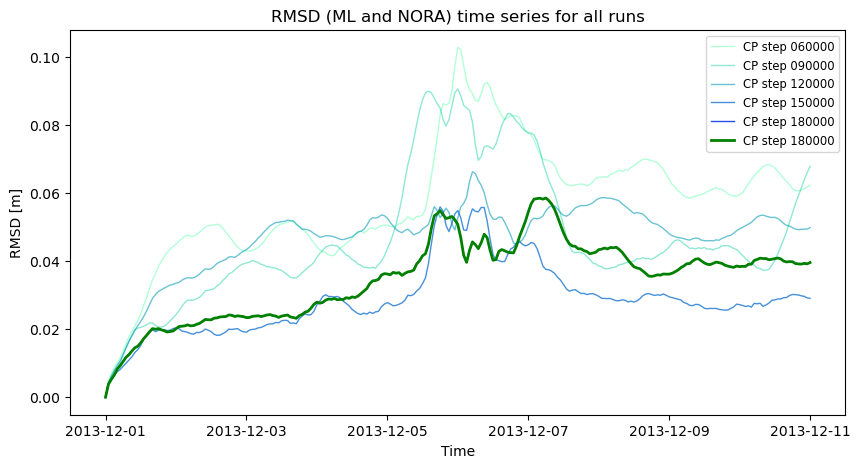

In [ ]:
# Plot the RMSE time series for all runs, color them by the CP step using viridis colormap
import matplotlib.cm as cm
fig, ax = plt.subplots(figsize=(10, 5))
for ifile_idx, ifile in enumerate(ifiles):
    # alpha = (ifile_idx+1)/len(ifiles)
    alpha = 0.3 + 0.7*(ifile_idx/len(ifiles))
    color = cm.winter_r(ifile_idx/len(ifiles))
    ax.plot(time, rmse[ifile_idx, :], label=f'CP step {ifile[-9:-3]}', lw=1, alpha=alpha, color=color)
    if ifile_idx == len(ifiles)-1:
        ax.plot(time, rmse[ifile_idx, :], label=f'CP step {ifile[-9:-3]}', lw=2, color='g')
ax.set_title(f'RMSD (ML and NORA) time series for all runs')
ax.set_xlabel('Time')
ax.set_ylabel('RMSD [m]')
ax.legend(fontsize='small')
plt.savefig(os.path.join(odir, f'{prefix}zeta_rmsd_timeseries.png'), dpi=100)
print(f'RMSD time series plot saved to {os.path.join(odir, f"{prefix}zeta_rmsd_timeseries.png")}')
plt.show()

### Do one year of data

In [31]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
import pandas as pd

In [27]:
# Run top cells first
plot_corrected = False
do_one_year = True
read_only_one_yearly_file = True

In [33]:
# odir = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/analysis/'
# Create odir if it does not exist
import os
if not os.path.exists(odir):
    os.makedirs(odir)
if plot_corrected:
    prefix = prefix.format('corr', f'{step:06d}')
else:
    prefix = prefix.format('uncorr', f'{step:06d}')
print(prefix)

train16yr_uncorr_2010-2018_


In [34]:
if not read_only_one_yearly_file:
    ifiles = glob.glob(multiyear_filestruct)
else:
    # If only dealing with one single yearly file:
    ifiles = [ifile]
ifiles.sort()
print(f'Found {len(ifiles)} files to process.')

Found 1 files to process.


In [35]:
ifiles

['/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/long_2010-01-02_78840h_step100000.nc']

In [36]:
# Store the rmse array as a pandas DataFrame and save as csv file
if do_one_year:
    import pandas as pd
    csv_file = os.path.join(odir, f'{prefix}zeta_rmsd_timeseries.csv')
    if not os.path.isfile(csv_file):
        # Calulate RMSD between inference and NORA surge for all time steps for all runs
        for ifile_idx, ifile in enumerate(ifiles):
            print(f'Processing file: {ifile}')
            nc = xr.open_dataset(ifile)
            zeta = nc.zeta
            # zeta2 = np.reshape(zeta.values, (zeta.shape[0], 570, 1014))
            time = nc.time
            if ifile_idx == 0:
                rmse = np.zeros((len(ifiles), len(time)))
                rmse_scaled = np.zeros((len(ifiles), len(time)))
                mean = np.zeros((len(ifiles), len(time)))
                ptile75 = np.zeros((len(ifiles), len(time)))
                ptile25 = np.zeros((len(ifiles), len(time)))
                maxval = np.zeros((len(ifiles), len(time)))
            # Find index of time in time_c
            timee = np.array([np.datetime64(t) for t in time.values])
            time_indices = np.where((timee_c >= timee[0]) & (timee_c <= timee[-1]))[0]
            for i in range(len(time)):
                zeta2 = np.reshape(zeta[i].values, (570, 1014))
                # Calculate mean, take into account nans and infs
                # Only select zeta_c where mask_c==1:
                # mean[ifile_idx, i] = zeta_c[time_indices[i], :][np.where(mask_c==1)].mean()
                statsfield = np.ma.masked_where(mask_c==0, zeta_c[time_indices[i], :])
                mean[ifile_idx, i] = np.ma.mean(statsfield)
                ptile75[ifile_idx, i] = np.nanpercentile(np.ma.filled(statsfield, np.nan), 75)
                ptile25[ifile_idx, i] = np.nanpercentile(np.ma.filled(statsfield, np.nan), 25)
                maxval[ifile_idx, i] = np.ma.max(statsfield)
                try:
                    if not plot_corrected:
                        # print(zeta2.shape, zeta_c[time_indices[i], :, :].shape, mask_c.shape)
                        rmse[ifile_idx, i] = np.sqrt(np.mean((zeta2[:,:]-zeta_c[time_indices[i], :, :]*mask_c)**2))
                    else:
                        rmse[ifile_idx, i] = np.sqrt(np.mean((zeta2[:,:]-zeta_c2[time_indices[i], :, :]*mask_c)**2))
                    # # Scale the RMSE by the mean water level of the NORA-Surge
                    # rmse_scaled[ifile_idx, i] = rmse[ifile_idx, i] / np.abs(mean[ifile_idx, i])
                    # # Scale the RMSE by the ptile75:
                    # rmse_scaled[ifile_idx, i] = rmse[ifile_idx, i] / (ptile75[ifile_idx, i])
                    # Scale by the maxval:
                    rmse_scaled[ifile_idx, i] = rmse[ifile_idx, i] / (maxval[ifile_idx, i])
                except Exception as e:
                    print(f"Error processing time index {i} in file {ifile}: {e}")
        # Create DataFrame and save to CSV
        if not read_only_one_yearly_file:
            # Extract the "yyyy-mm-dd" part from the filenames for the index
            indexes = [os.path.basename(f)[0:10] for f in ifiles]
            rmse_df = pd.DataFrame(rmse, index=indexes, columns=[str(t) for t in np.arange(time.shape[0])])
            rmse_scaled_df = pd.DataFrame(rmse_scaled, index=indexes, columns=[str(t) for t in np.arange(time.shape[0])])
            mean_df = pd.DataFrame(mean, index=indexes, columns=[str(t) for t in np.arange(time.shape[0])])
        else:
            rmse_df = pd.DataFrame(rmse, index=['singlefile'], columns=[str(t) for t in np.arange(time.shape[0])])
            rmse_scaled_df = pd.DataFrame(rmse_scaled, index=['singlefile'], columns=[str(t) for t in np.arange(time.shape[0])])
            mean_df = pd.DataFrame(mean, index=['singlefile'], columns=[str(t) for t in np.arange(time.shape[0])])
            ptile25_df = pd.DataFrame(ptile25, index=['singlefile'], columns=[str(t) for t in np.arange(time.shape[0])])
            ptile75_df = pd.DataFrame(ptile75, index=['singlefile'], columns=[str(t) for t in np.arange(time.shape[0])])
            maxval_df = pd.DataFrame(maxval, index=['singlefile'], columns=[str(t) for t in np.arange(time.shape[0])])
        rmse_df.to_csv(csv_file)
        print(f'RMSD time series saved to {os.path.join(odir, f"{prefix}zeta_rmsd_timeseries.csv")}')
        rmse_scaled_df.to_csv(os.path.join(odir, f'{prefix}zeta_rmsd_scaled_timeseries.csv'))
        mean_df.to_csv(os.path.join(odir, f'{prefix}zeta_mean_timeseries.csv'))
        print(f'Scaled RMSD time series saved to {os.path.join(odir, f"{prefix}zeta_rmsd_scaled_timeseries.csv")}')
        print(f'Mean water level time series saved to {os.path.join(odir, f"{prefix}zeta_mean_timeseries.csv")}')
        ptile25_df.to_csv(os.path.join(odir, f'{prefix}zeta_ptile25_timeseries.csv'))
        ptile75_df.to_csv(os.path.join(odir, f'{prefix}zeta_ptile75_timeseries.csv'))
        maxval_df.to_csv(os.path.join(odir, f'{prefix}zeta_maxval_timeseries.csv'))
    else:
        print(f'CSV file {csv_file} already exists.')
        rmse_df = pd.read_csv(csv_file, index_col=0)

CSV file /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/train16yr_uncorr_2010-2018_zeta_rmsd_timeseries.csv already exists.


In [37]:
rmsd_file4 = os.path.join(commondir, 'longrun_5years_newgraph_90s_uncorr/inference/figures/train4yr_uncorr_2010-2018_zeta_rmsd_timeseries.csv')
rmsd_file16 = os.path.join(commondir, 'longrun_10years_newgraph_90s_uncorr/inference/figures/train16yr_uncorr_2010-2018_zeta_rmsd_timeseries.csv')
rmsd_df4 = pd.read_csv(rmsd_file4, index_col=0)
rmsd_df16 = pd.read_csv(rmsd_file16, index_col=0)

RMSD time series plot saved to /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/train16yr_uncorr_2010-2018_zeta_rmsd_timeseries.png


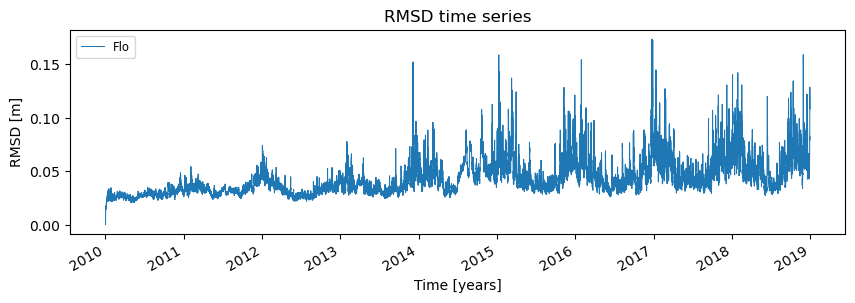

In [40]:
# Plot the RMSD time series for all runs, color them by the CP step using viridis colormap
if do_one_year:
    import matplotlib.cm as cm
    fig, ax = plt.subplots(figsize=(10, 3))
    # ax.plot(np.arange(rmse_df.shape[1]), np.median(rmse_df, axis=0), label=f'RMSE', lw=1)
    # ax.plot(time, np.median(rmse_df, axis=0), label=f'RMSD', lw=1)
    # ax.plot(time, np.median(rmsd_df4, axis=0), label=f'Train 4 years', lw=0.75, alpha=0.7)
    # ax.plot(time, np.median(rmsd_df16, axis=0), label=f'Train 16 years', lw=0.75, alpha=0.7)
    ax.plot(time, np.median(rmsd_df16, axis=0), label=f'Flo', lw=0.75, alpha=1)
    # ax.plot(time, maxval_df.loc['singlefile'], label='Max Value', lw=0.75, alpha=0.7)
    # ax.plot(np.arange(rmse_scaled_df.shape[1]), np.median(rmse_scaled_df, axis=0), label=f'RMSE', lw=1)
    # ax.set_xlim(0,480)
    # Only show the first 20 days
    # ax.set_xlim(np.datetime64('2010-01-02'), np.datetime64('2010-01-22'))
    # ax.set_ylim(0,0.050)
    # ax.set_ylim(0,5)
    # ax.set_title(f'RMSD time series for all runs')
    ax.set_title(f'RMSD time series')
    ax.set_xlabel('Time [years]')
    ax.set_ylabel('RMSD [m]')
    ax.legend(loc='upper left', fontsize='small')
    # # Add a plot for the difference between the two median RMSD time series with a secondary y-axis
    # ax2 = ax.twinx()
    # ax2.plot(time, np.median(rmsd_df4, axis=0)-np.median(rmsd_df16, axis=0), label='Difference (4yr - 16yr)', color='grey', lw=0.5, alpha=0.7)
    # ax2.set_ylabel('RMSD Difference [m]', color='grey')
    # ax2.tick_params(axis='y', labelcolor='grey')
    # ax2.axhline(0, color='black', lw=0.5, ls='--')
    # ax2.legend(loc='upper right', fontsize='small')
    # Fix the labels on the x-axis to show dates properly
    fig.autofmt_xdate()
    plt.savefig(os.path.join(odir, f'{prefix}zeta_rmsd_timeseries.png'), dpi=100)
    print(f'RMSD time series plot saved to {os.path.join(odir, f"{prefix}zeta_rmsd_timeseries.png")}')
    plt.show()

RMSD time series with trend saved to /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/train16yr_uncorr_2010-2018_zeta_rmsd_timeseries_with_trend.png


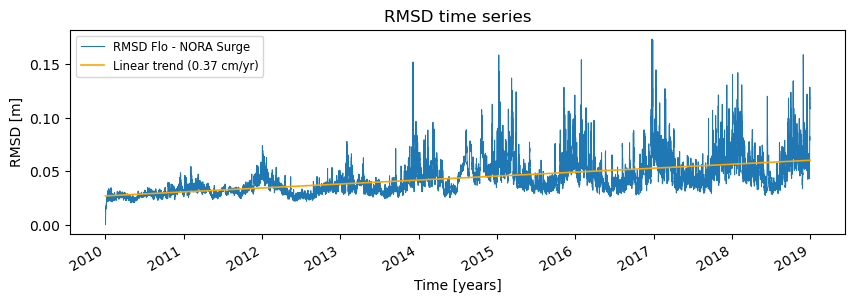

In [46]:
if do_one_year:
    y = np.median(rmsd_df16.values, axis=0)
    x_time = np.array(time.values)
    x_num = x_time.astype("datetime64[h]").astype(np.int64)

    slope, intercept = np.polyfit(x_num, y, 1)
    y_fit = slope * x_num + intercept
    slope_per_year = slope * 24 * 365 *100  # Convert from per hour to per year and from m to cm

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(time, y, label="RMSD Flo - NORA Surge", lw=0.75, alpha=1.0)
    ax.plot(time, y_fit, color="orange", lw=1.2, label=f"Linear trend ({slope_per_year:.2f} cm/yr)")

    ax.set_title("RMSD time series")
    ax.set_xlabel("Time [years]")
    ax.set_ylabel("RMSD [m]")
    ax.legend(loc="upper left", fontsize="small")

    fig.autofmt_xdate()
    outfile = os.path.join(odir, f"{prefix}zeta_rmsd_timeseries_with_trend.png")
    plt.savefig(outfile, dpi=100)
    print(f"RMSD time series with trend saved to {outfile}")
    plt.show()

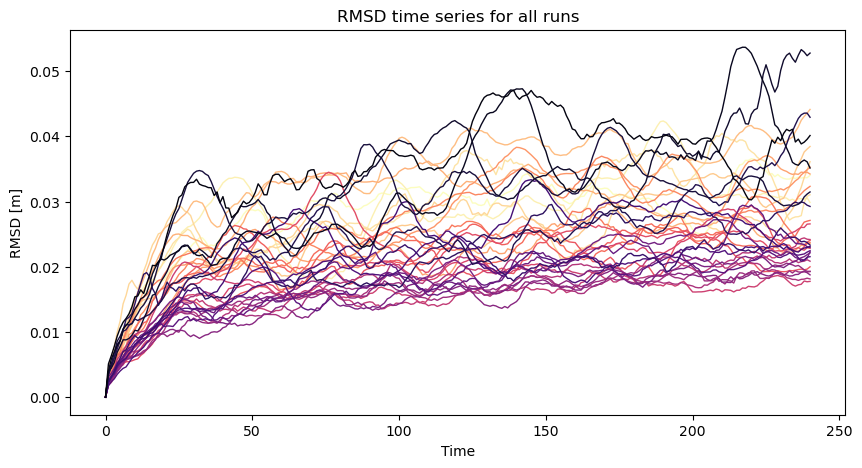

In [24]:
# Plot the RMSE time series for all runs, color them by the CP step using viridis colormap
if do_one_year:
    import matplotlib.cm as cm
    fig, ax = plt.subplots(figsize=(10, 5))
    for ifile_idx in np.arange(rmse_df.shape[0]):
        ax.plot(np.arange(rmse_df.shape[1]), rmse_df.values[ifile_idx, :], lw=1, color=cm.magma_r(ifile_idx/rmse_df.shape[0]))
    ax.set_title(f'RMSD time series for all runs')
    ax.set_xlabel('Time')
    ax.set_ylabel('RMSD [m]')
    plt.show()

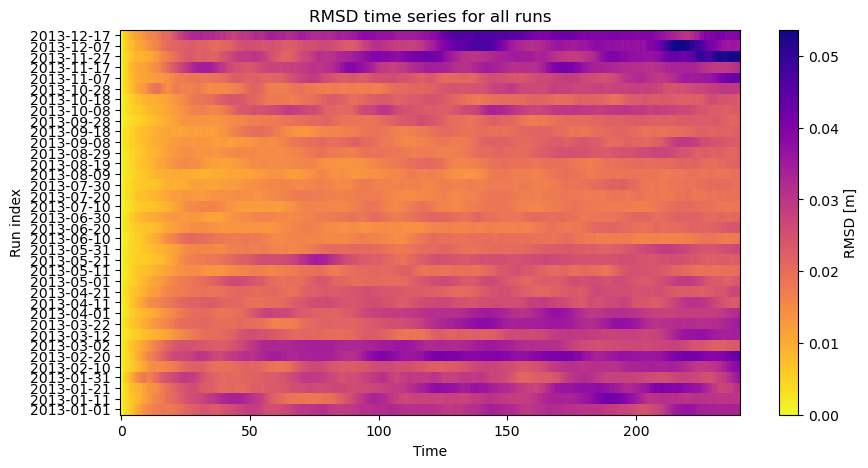

In [25]:
# Plot rmse_df as pcolormesh
if do_one_year:
    fig, ax = plt.subplots(figsize=(10, 5))
    pcm = ax.pcolormesh(rmse_df.columns.astype(int), rmse_df.index, rmse_df.values, cmap='plasma_r')
    ax.set_title(f'RMSD time series for all runs')
    ax.set_xlabel('Time')
    ax.set_ylabel('Run index')
    fig.colorbar(pcm, ax=ax, label='RMSD [m]')
    plt.show()

In [26]:
# Plot all dataframes in csv file in one plot:
filestruct = os.path.join(commondir, '*', 'inference/figures', 'train*_10d_*zeta_rmsd_timeseries.csv')
print(f'Looking for RMSD files with structure: {filestruct}')
rmsd_files = glob.glob(filestruct)
rmsd_files.sort()
print(f'Found {len(rmsd_files)} RMSD files')

Looking for RMSD files with structure: /lustre/storeB/users/nilsmk/anemoi-datasets/output/*/inference/figures/train*_10d_*zeta_rmsd_timeseries.csv
Found 8 RMSD files


Processing RMSD file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/train16yr_uncorr_10d_025000zeta_rmsd_timeseries.csv
Processing RMSD file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/train16yr_uncorr_10d_050000zeta_rmsd_timeseries.csv
Processing RMSD file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/train16yr_uncorr_10d_075000zeta_rmsd_timeseries.csv
Processing RMSD file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/train16yr_uncorr_10d_100000zeta_rmsd_timeseries.csv
Processing RMSD file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_5years_newgraph_90s_uncorr/inference/figures/train4yr_uncorr_10d_025000zeta_rmsd_timeseries.csv
Processing RMSD file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_5years_newgraph_90s_uncorr

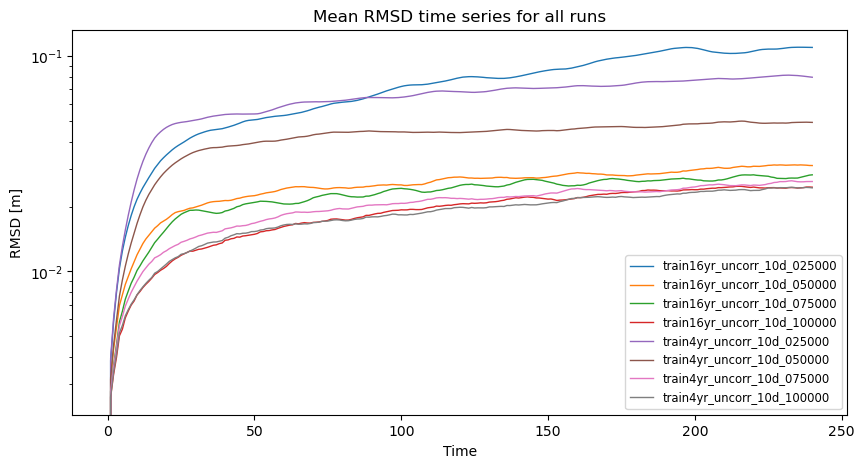

In [30]:
# Plot the mean over axis 0 for each file in one plot
fig, ax = plt.subplots(figsize=(10, 5))
for rmsd_file in rmsd_files:
    print(f'Processing RMSD file: {rmsd_file}')
    rmse_df = pd.read_csv(rmsd_file, index_col=0)
    mean_rmse = np.mean(rmse_df.values, axis=0)
    label = os.path.basename(rmsd_file).replace('zeta_rmsd_timeseries.csv', '')
    ax.plot(np.arange(mean_rmse.shape[0]), mean_rmse, label=label, lw=1)
ax.set_title(f'Mean RMSD time series for all runs')
ax.set_xlabel('Time')
ax.set_ylabel('RMSD [m]')
ax.legend(fontsize='small')
# set logscale on y axis
ax.set_yscale('log')
# plt.savefig(os.path.join(odir, f'all_runs_mean_zeta_rmsd_timeseries.png'), dpi=100)
# print(f'Mean RMSD time series plot saved to {os.path.join(odir, "all_runs_mean_zeta_rmsd_timeseries.png")}')    
plt.show()

In [36]:
avg_rmsd = np.zeros((int(len(rmsd_files)/2), 2))
i16 = 0
i_other = 0
for i, rmsd_file in enumerate(rmsd_files):
    print(f'Processing RMSD file: {rmsd_file}')
    if '16yr' in rmsd_file:
        idx = 0
        i16 += 1
    else:
        idx = 1
        i_other += 1
    rmse_df = pd.read_csv(rmsd_file, index_col=0)
    mean_rmse = np.mean(rmse_df.values, axis=0)
    overall_mean = np.mean(mean_rmse)
    if '16yr' in rmsd_file:
        avg_rmsd[i16-1, idx] = overall_mean
    else:
        avg_rmsd[i_other-1, idx] = overall_mean

Processing RMSD file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/train16yr_uncorr_10d_025000zeta_rmsd_timeseries.csv
Processing RMSD file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/train16yr_uncorr_10d_050000zeta_rmsd_timeseries.csv
Processing RMSD file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/train16yr_uncorr_10d_075000zeta_rmsd_timeseries.csv
Processing RMSD file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/train16yr_uncorr_10d_100000zeta_rmsd_timeseries.csv
Processing RMSD file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_5years_newgraph_90s_uncorr/inference/figures/train4yr_uncorr_10d_025000zeta_rmsd_timeseries.csv
Processing RMSD file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_5years_newgraph_90s_uncorr

In [39]:
avg_rmsd.shape

(4, 2)

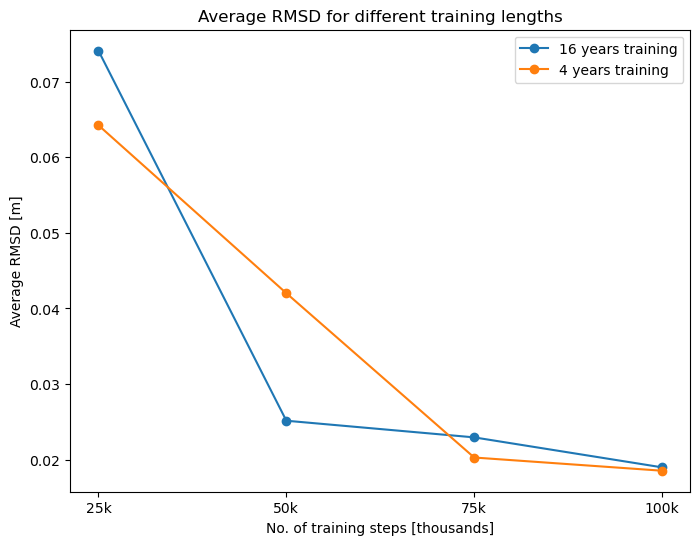

In [43]:
fig, ax = plt.subplots(figsize=(8, 6))
labels = ['16 years training', '4 years training']
xticks = ['25k', '50k', '75k', '100k']
ax.plot(np.arange(avg_rmsd.shape[0]), avg_rmsd[:,0], label='16 years training', marker='o')
ax.plot(np.arange(avg_rmsd.shape[0]), avg_rmsd[:,1], label='4 years training', marker='o')
ax.set_title('Average RMSD for different training lengths')
ax.set_xlabel('No. of training steps [thousands]')
ax.set_ylabel('Average RMSD [m]')
ax.set_xticks(np.arange(len(xticks)))
ax.set_xticklabels(xticks)
ax.legend()
plt.show()